# DATASET DI IMMAGINI

## vedremo in altri esercizi invece come gestire dataset di numeri, insomma..con dati numerici invece che immagini 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def str2image(s):
    #Faccio lo split perchè la stringa ha tanti spazi al suo interno e da lista la trasformo in un array di numeri per lavorarci sopra
    test_face_array = np.array([int(p) for p in s.split(" ")])
    #Lo shape è 2304, cioè 48*48 e a me serve che sia proprio così! Un 48*48, lo divido
    image_test_face = test_face_array.reshape((48, 48))
    return image_test_face

# Un dataset di espressioni facciali umane

il file `fer2013.csv` è un file csv che contiene immagini di espressioni facciali in risoluzione 48 x 48. Ogni riga contiene una immagine e l'emozione associata all'espressione dell'immagine.

Un dataset disolito è un file csv, una tabella con all'interno dati utili.

Le immagini sono in **scala di grigi!**

Leggere il file con pandas

In [3]:
data = pd.read_csv("./fer2013.csv") #data è un oggetto di tipo DataFrame

I **DataFrame** sono gli oggetti più importanti di Pandas, rappresentano una tabella

In [4]:
# Stampare le prime 5 righe della tabella
data.head(5)

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [8]:
#Stampare le ultime 5 righe della tabella, colonna pixels e Usage sono stringhe
data.tail(5)

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


La prima colonna si definisce **indice** un po' come una "chiave primaria"

In [7]:
#Informazioni sul DataFrame 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


(0 = Angry, 1 = Disgust, 2 = Fear, 3 = Happy, 4 = Sad, 5 = Surprise, 6 = Neutral)

In [13]:
emotion = 0
#Voglio tutte le righe del dataset che rappresentano persone arrabbiate
angry = data[data["emotion"]==emotion] #dentro le quadre c'è la query
angry #Anch'egli è un dataframe

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
10,0,30 24 21 23 25 25 49 67 84 103 120 125 130 139...,Training
22,0,123 125 124 142 209 226 234 236 231 232 235 22...,Training
23,0,8 9 14 21 26 32 37 46 52 62 72 70 71 73 76 83 ...,Training
...,...,...,...
35845,0,149 141 141 137 143 157 166 123 217 230 220 21...,PrivateTest
35849,0,90 82 42 36 33 45 81 112 122 139 155 149 152 1...,PrivateTest
35854,0,139 141 141 138 152 164 176 160 137 118 106 95...,PrivateTest
35881,0,181 177 176 156 178 144 136 132 122 107 131 16...,PrivateTest


In [15]:
#Pre prendere una colonna: (In questo caso pixels)
angry["pixels"]

0        70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        151 150 147 155 148 133 111 140 170 174 182 15...
10       30 24 21 23 25 25 49 67 84 103 120 125 130 139...
22       123 125 124 142 209 226 234 236 231 232 235 22...
23       8 9 14 21 26 32 37 46 52 62 72 70 71 73 76 83 ...
                               ...                        
35845    149 141 141 137 143 157 166 123 217 230 220 21...
35849    90 82 42 36 33 45 81 112 122 139 155 149 152 1...
35854    139 141 141 138 152 164 176 160 137 118 106 95...
35881    181 177 176 156 178 144 136 132 122 107 131 16...
35884    17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...
Name: pixels, Length: 4953, dtype: object

In [19]:
#Salvo la colonna in un array numpy
array_pixels = angry["pixels"].to_numpy()

In [22]:
array_pixels.dtype #è un array di tipo object! E al suo interno ci sono stringhe di numeri che sono le immagini

dtype('O')

In [23]:
#La faccia della prima riga degli arrabbiati
test_face = array_pixels[0]

In [24]:
type(test_face)

str

In [27]:
#Faccio lo split perchè la stringa ha tanti spazi al suo interno e da lista la trasformo in un array di numeri per lavorarci sopra
test_face_array = np.array([int(p) for p in test_face.split(" ")])

In [28]:
test_face_array.dtype

dtype('int64')

In [29]:
#Lo shape è 2304, cioè 48*48 e a me serve che sia proprio così! Un 48*48, lo divido
image_test_face = test_face_array.reshape((48, 48))

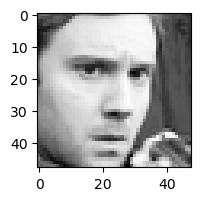

In [36]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(str2image(test_face), cmap="Greys_r")
plt.show()

# Grafico per immagini plottate

Ora plottiamo un grafico per le emozioni, a caso

In [38]:
emotions_list = list(range(0,7)) #Le emozioni tanto sono da 0 a 6
emotions_list

[0, 1, 2, 3, 4, 5, 6]

In [49]:
#Dizionario per emozioni (Da avere il nome per il numero)
diz_emotions = {0:"Angry", 1:"Disgust", 2:"Fear", 3:"Happy", 4:"Sad", 5:"Surprise", 6:"Neutral"}

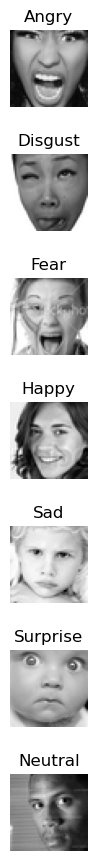

In [51]:
fig, axs = plt.subplots(nrows=7, figsize = (1, 11))
#facendo così non serve emotions_list
for emotion, ax in enumerate(axs):
    #Quì posso scrivere il codice che mi prende le facce di un tipo
    selected = data[data["emotion"]==emotion]
    array = selected["pixels"].to_numpy()
    #prendo una faccia per tipo a caso
    face_str = np.random.choice(array)
    ax.imshow(str2image(face_str), cmap = "binary_r")
    ax.set_axis_off()
    ax.set_title(diz_emotions[emotion])
    
plt.show()

## Creare un grafico 7 * 7 in cui ogni riga rappresenta 7 facce on la stessa emozione. Ogni riga rappresenta una emozione

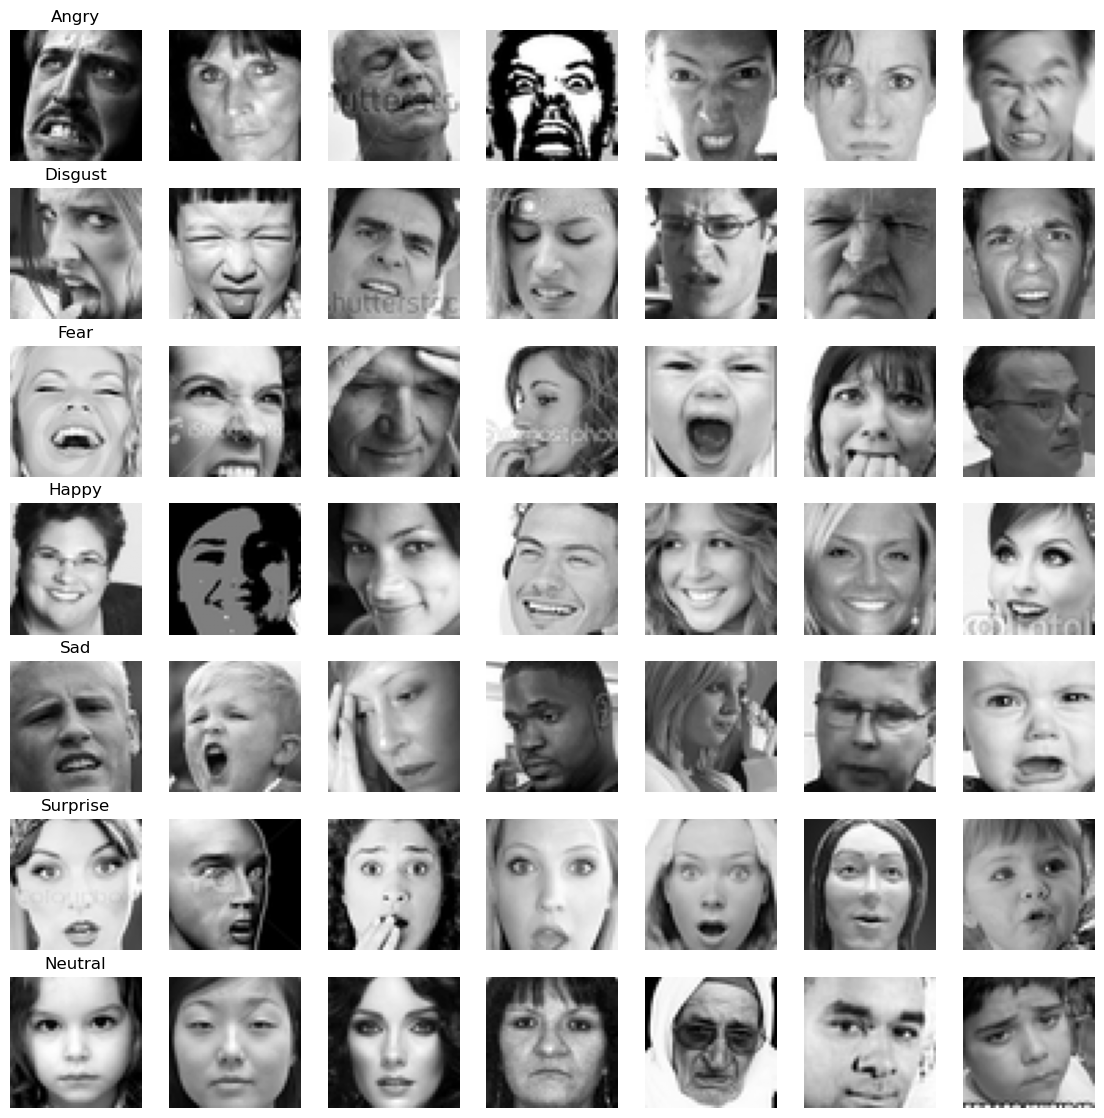

In [66]:
fig, axs = plt.subplots(nrows=7, ncols=7, figsize = (14, 14))
#facendo così non serve emotions_list
for row in range(7):
    for col in range(7):
        #una riga è una emozione, una faccia
        emotion = row
        #Quì posso scrivere il codice che mi prende le facce di un tipo
        selected = data[data["emotion"]==emotion]
        array = selected["pixels"].to_numpy()
        #prendo una faccia per tipo a caso
        face_str = np.random.choice(array)
        axs[row, col].imshow(str2image(face_str), cmap = "binary_r")
        axs[row, col].set_axis_off()
        #Solo alla prima colonna di tutti i tipi metto il titolo
        if col == 0:
            axs[row, col].set_title(diz_emotions[emotion])
    
plt.show()